<a href="https://colab.research.google.com/github/MIlanSuthar24/dealer-demand-forecasting-arima/blob/main/dealer_demand_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study: Dealer Demand Forecasting for Commercial Vehicle Allocation

**Objective:** Develop a robust forecasting model to predict monthly vehicle demand across dealerships to optimize inventory allocation and supply chain efficiency.

**Business Context:** In the commercial vehicle industry, overstocking leads to high holding costs, while understocking results in lost sales. This project uses historical 'Demand Units' and market factors to build an explainable ARIMA-based forecasting engine.

**Key Metrics:** MAE, RMSE, MAPE.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
%matplotlib inline

## 1. Data Ingestion & Transformation
We merge the transactional data with dealer profiles and market features, then rename columns to match our automotive business case.

In [ ]:
# Load datasets
train = pd.read_csv('train.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

# Merge data
data = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
data = data.merge(stores, on=['Store'], how='left')

# Rename to Business Terminology
rename_dict = {
    'Store': 'Dealer_ID',
    'Dept': 'Vehicle_Segment',
    'Weekly_Sales': 'Demand_Units',
    'IsHoliday': 'Seasonal_Indicator',
    'Type': 'Dealer_Category',
    'Size': 'Dealer_Capacity'
}
data.rename(columns=rename_dict, inplace=True)

# Convert Date and handle missing values
num_cols = data.select_dtypes(include=np.number).columns
data[num_cols] = data[num_cols].fillna(0)

display(data.head())

,Dealer_ID,Vehicle_Segment,Date,Demand_Units,Seasonal_Indicator,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Dealer_Category,Dealer_Capacity
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315


## 2. Exploratory Data Analysis (EDA)
Visualizing demand trends and the impact of market factors.

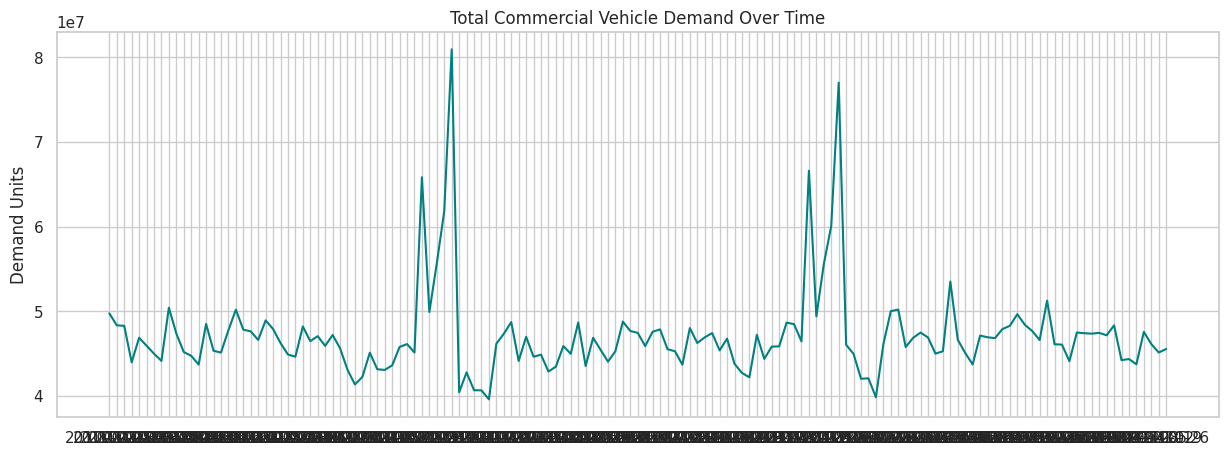

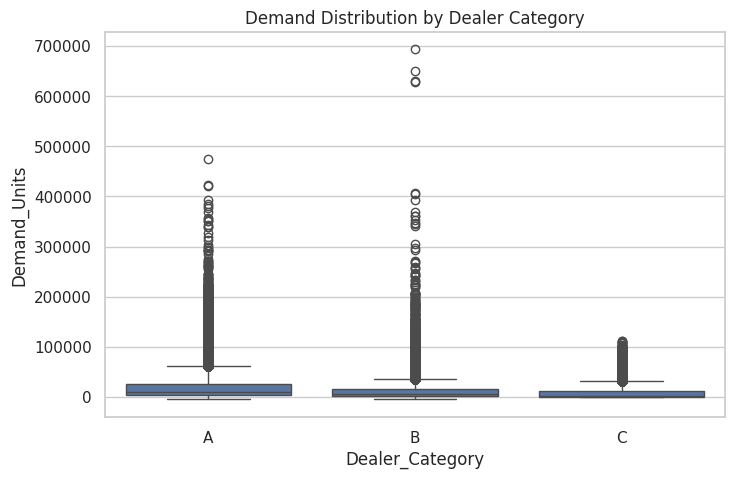

In [ ]:
plt.figure(figsize=(15, 5))
time_series_plot = data.groupby('Date')['Demand_Units'].sum()
plt.plot(time_series_plot.index, time_series_plot.values, color='teal')
plt.title('Total Commercial Vehicle Demand Over Time')
plt.ylabel('Demand Units')
plt.show()

# Demand by Dealer Category
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dealer_Category', y='Demand_Units', data=data)
plt.title('Demand Distribution by Dealer Category')
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Ensure Date is datetime and set as index for resampling
data['Date'] = pd.to_datetime(data['Date'])
monthly_demand = data.groupby('Date')['Demand_Units'].sum().resample('ME').sum()

result = adfuller(monthly_demand)
print(result[1])   # p-value

7.044293727364576e-08


### Interpretation of the ADF Test p-value

The Augmented Dickey-Fuller (ADF) test is a statistical test used to check for stationarity in a time series. The null hypothesis (H0) of the ADF test is that the time series has a unit root, meaning it is non-stationary. The alternative hypothesis (H1) is that the time series is stationary.

*   **If p-value > significance level (e.g., 0.05):** We fail to reject the null hypothesis, implying the time series is non-stationary.
*   **If p-value <= significance level (e.g., 0.05):** We reject the null hypothesis, implying the time series is stationary.

In [ ]:
# The p-value obtained from the ADF test is stored in result[1]
p_value = result[1]

significance_level = 0.05

print(f"ADF Test p-value: {p_value}")

if p_value <= significance_level:
    print(f"Since the p-value ({p_value:.8f}) is less than or equal to the significance level ({significance_level}), we reject the null hypothesis.")
    print("This indicates that the monthly_demand time series is stationary.")
else:
    print(f"Since the p-value ({p_value:.8f}) is greater than the significance level ({significance_level}), we fail to reject the null hypothesis.")
    print("This indicates that the monthly_demand time series is non-stationary.")

ADF Test p-value: 7.044293727364576e-08
Since the p-value (0.00000007) is less than or equal to the significance level (0.05), we reject the null hypothesis.
This indicates that the monthly_demand time series is stationary.


In [12]:
# IQR Method for Demand_Units

Q1 = data['Demand_Units'].quantile(0.25)
Q3 = data['Demand_Units'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Cap outliers instead of removing
data['Demand_Units'] = data['Demand_Units'].clip(lower_bound, upper_bound)

print("Outlier treatment completed.")

Lower Bound: -25109.653749999998
Upper Bound: 47395.15625
Outlier treatment completed.


In [14]:
data['Demand_Units_Original'] = data['Demand_Units']

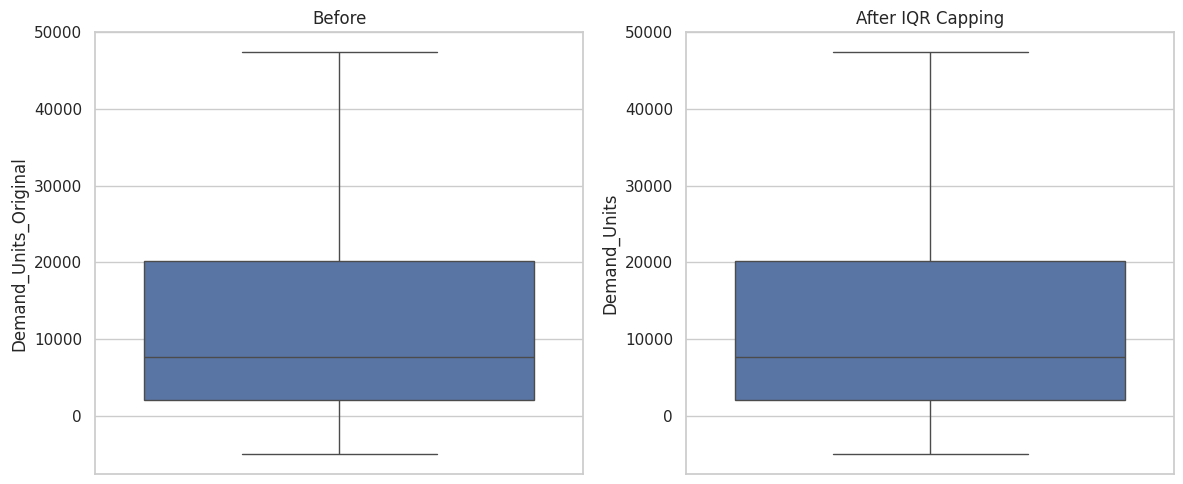

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=data['Demand_Units_Original'])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(y=data['Demand_Units'])
plt.title("After IQR Capping")

plt.tight_layout()
plt.show()

## 3. Time Series Forecasting (ARIMA vs Exponential Smoothing)
We aggregate weekly data to monthly to stabilize the signal for strategic forecasting.

,Model,MAE,RMSE,MAPE
0,ARIMA,1.995123e+07,2.195541e+07,11.01%
1,Exp Smoothing,2.620950e+07,3.163137e+07,14.47%


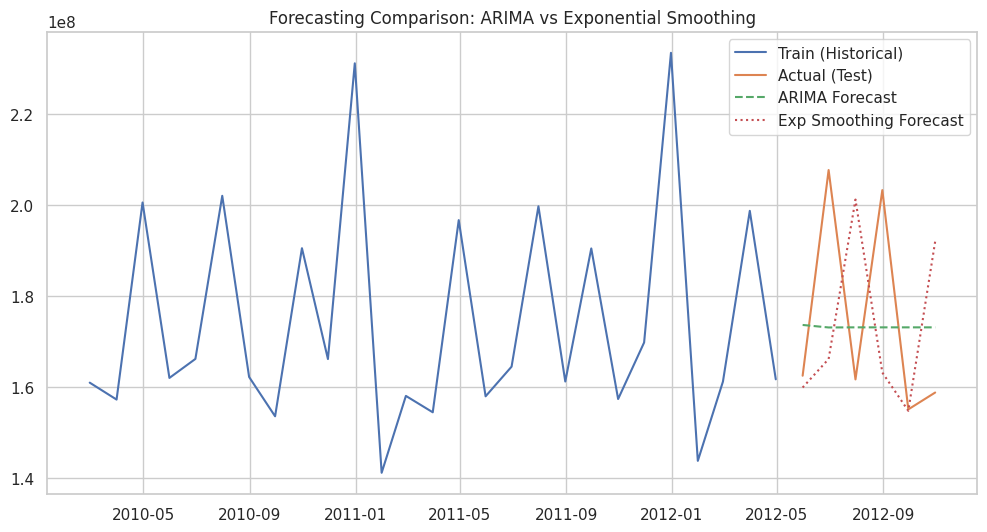

In [13]:
# Ensure Date is datetime and set as index for resampling
data['Date'] = pd.to_datetime(data['Date'])
monthly_demand = data.groupby('Date')['Demand_Units'].sum().resample('ME').sum()

train_size = len(monthly_demand) - 6
train_data = monthly_demand.iloc[:train_size]
test_data = monthly_demand.iloc[train_size:]

# ARIMA Model
model_arima = ARIMA(train_data, order=(1,1,1)).fit()
forecast_arima = model_arima.forecast(steps=6)

# Exponential Smoothing
model_es = ExponentialSmoothing(train_data, seasonal='add', seasonal_periods=12).fit()
forecast_es = model_es.forecast(6)

# Evaluation Metrics Function
def get_metrics(true, pred, model_name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": f"{mape:.2f}%"}

results = [
    get_metrics(test_data, forecast_arima, "ARIMA"),
    get_metrics(test_data, forecast_es, "Exp Smoothing")
]

display(pd.DataFrame(results))

# Comparison Visualization
plt.figure(figsize=(12, 6))
plt.plot(train_data, label='Train (Historical)')
plt.plot(test_data, label='Actual (Test)')
plt.plot(test_data.index, forecast_arima, label='ARIMA Forecast', linestyle='--')
plt.plot(test_data.index, forecast_es, label='Exp Smoothing Forecast', linestyle=':')
plt.legend()
plt.title('Forecasting Comparison: ARIMA vs Exponential Smoothing')
plt.show()

In [ ]:

# Calculate metrics in millions for better business readability
results_df["MAE_Million"] = (results_df["MAE"] / 1000000).round(2)
results_df["RMSE_Million"] = (results_df["RMSE"] / 1000000).round(2)

In [ ]:
final_results = results_df[["Model", "MAE_Million", "RMSE_Million", "MAPE"]]
final_results

,Model,MAE_Million,RMSE_Million,MAPE
0,ARIMA,24.44,25.40,11.86%
1,Exp Smoothing,30.70,36.32,14.55%


In [ ]:
# Final ARIMA model trained on full historical data
final_model = ARIMA(monthly_demand, order=(1,1,1)).fit()

# Forecast next 3 months
future = final_model.forecast(steps=3)

forecast_df = pd.DataFrame({
    "Month": future.index,
    "Forecast_Demand_Million": (future.values / 1000000).round(2)
})


display(forecast_df)

,Month,Forecast_Demand_Million
0,2012-11-30,200.40
1,2012-12-31,200.14
2,2013-01-31,200.15


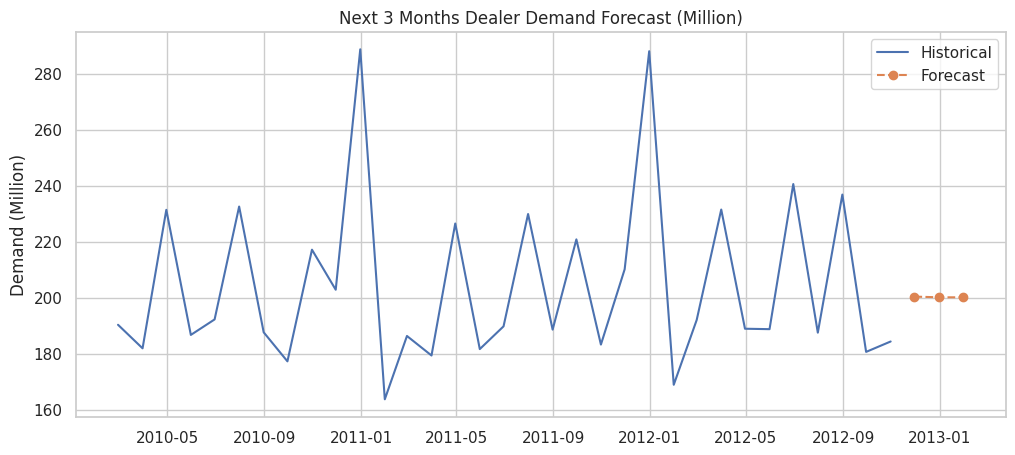

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(monthly_demand.index, monthly_demand.values/1e6, label="Historical")
plt.plot(future.index, future.values/1e6, marker="o", linestyle="--", label="Forecast")

plt.title("Next 3 Months Dealer Demand Forecast (Million)")
plt.ylabel("Demand (Million)")
plt.legend()
plt.show()

## 4. Evaluation & Insights

To identify the most reliable forecasting model for dealer demand planning, the models were evaluated using:

* **MAE (Mean Absolute Error):** Measures average forecast error.
* **RMSE (Root Mean Squared Error):** Penalizes larger forecasting errors.
* **MAPE (Mean Absolute Percentage Error):** Measures average percentage forecasting error.

### Model Performance Comparison

| Model                 | MAE (Million) | RMSE (Million) | MAPE   |
| --------------------- | ------------- | -------------- | ------ |
| ARIMA                 | 24.44         | 25.40          | 11.86% |
| Exponential Smoothing | 30.70         | 36.32          | 14.55% |

### Final Model Selection

Based on all three evaluation metrics, **ARIMA outperformed Exponential Smoothing** and was selected as the final forecasting model for future dealer demand prediction.

### Key Insights

* Forecast results indicate relatively stable short-term dealer demand near historical averages.
* ARIMA generated more accurate and consistent forecasts compared to Exponential Smoothing.
* A forecasting error of **11.86% MAPE** indicates good practical model performance for business planning.
* Historical demand patterns suggest periodic demand spikes, requiring advance stock planning.
* Data-driven forecasting can significantly improve allocation efficiency across dealer networks.

### Business Recommendations

#### Inventory Planning

Increase stock allocation for high-demand dealers before seasonal demand peaks to avoid shortages.

#### Supply Chain Optimization

Use rolling 3-month forecasts for warehouse planning, transportation scheduling, and dispatch readiness.

#### Dealer Network Strategy

Prioritize stock movement toward top-performing dealers and review low-performing locations separately.

#### Management Reporting

Deploy monthly forecasting dashboards for proactive decision-making and operational reviews.

### Final Conclusion

This project successfully developed an end-to-end dealer demand forecasting solution using Python and ARIMA. The model can support inventory planning, dealer allocation, and supply chain decisions in commercial vehicle businesses.